# Data Cleaning and Preprocessing Pipeline
This notebook focuses exclusively on the data cleaning and preprocessing stage for our AI-based financial risk analysis project.
The dataset contains borrower information (e.g., income, loan amount, employment length, credit history) and whether they defaulted.
Our goal is to prepare this data so that it is ready for machine learning models (No modeling is performed here).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set plot style and display options for clear visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
First, we load the credit risk dataset from a CSV file. We'll examine the first few rows and the overall shape of the data to understand its basic structure.

In [2]:
# Load dataset
# We are specifically loading the credit risk dataset for this project.
df = pd.read_csv('credit_risk_dataset.csv')

print("Dataset 'credit_risk_dataset.csv' loaded successfully.")

# Show first few rows
display(df.head())

Dataset 'credit_risk_dataset.csv' loaded successfully.


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Show dataset shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 32581 rows, 12 columns


## 2. Initial Exploration
Understanding our dataset before transforming it:
- `info()` tells us column names, non-null counts, and data types.
- `describe()` provides statistical summaries for numerical features.
- We also identify numerical vs categorical features.

In [4]:
# General information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Statistical summary of numerical columns
display(df.describe())

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
# Identify numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 3. Handling Missing Values
Datasets often contain missing elements. We identify them and treat them using statistical methods:
- We use the **median** for `person_income` to avoid skewing by extremely high incomes.
- We use the **median** for `person_emp_length` as well.
- Rows with overwhelmingly missing crucial data could also be dropped, but imputation is preferred for this phase.

In [7]:
# Show missing value counts
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data[missing_data > 0])

Missing values per column:
 person_emp_length     895
loan_int_rate        3116
dtype: int64


In [8]:
# Handle missing values dynamically for ALL columns to prevent NaN crashes later
# 1. Fill missing numerical values with their median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val:.2f}")

# 2. Fill missing categorical strings with their mode (most frequent value)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# Verify total missing values are completely extinguished
remaining_nulls = df.isnull().sum().sum()
print(f"\nTotal missing values left: {remaining_nulls}")


Filled missing values in 'person_emp_length' with median: 4.00
Filled missing values in 'loan_int_rate' with median: 10.99

Total missing values left: 0


## 4. Handling Duplicates
Duplicate rows can improperly weight algorithms, affecting evaluation. We detect and remove exact matches.

In [9]:
# Check duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove if present
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")

Number of duplicate rows: 165
Duplicates removed.


## 5. Outlier Detection & Treatment
Outliers are extreme values that deviate from other observations on data. They may indicate variability, errors, or anomalies.
- Plotting boxplots helps visualize outliers.
- We remove logical impossibilities (like unrealistic age or employment length).
- Then we cap mathematical outliers using the Interquartile Range (IQR) method.

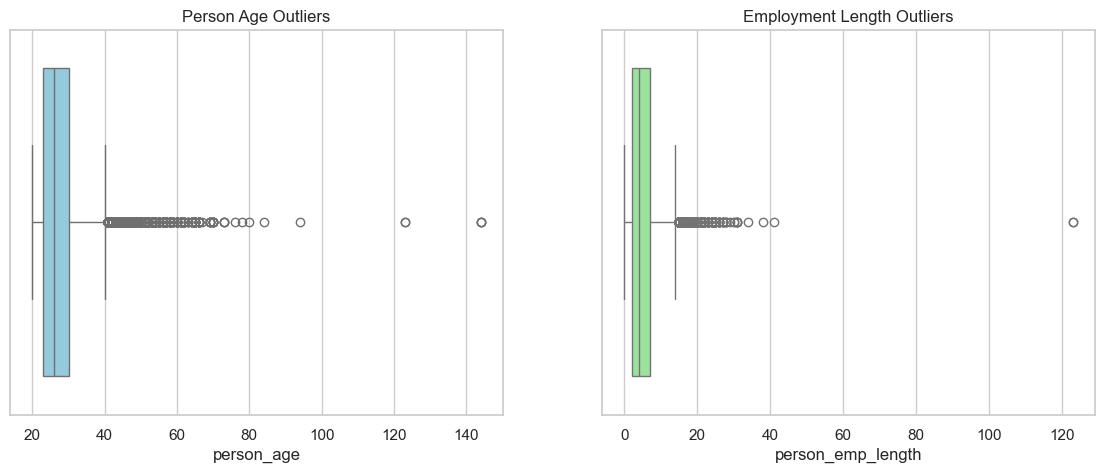

In [10]:
# Use boxplots to visualize outliers in numerical fields
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['person_age'], ax=axes[0], color='skyblue')
axes[0].set_title('Person Age Outliers')

sns.boxplot(x=df['person_emp_length'], ax=axes[1], color='lightgreen')
axes[1].set_title('Employment Length Outliers')
plt.show()

In [11]:
# 1. Remove logical errors
initial_len = len(df)
df = df[(df['person_age'] <= 100)]
df = df[(df['person_emp_length'] <= 60)]
print(f"Removed {initial_len - len(df)} rows with logically impossible values.")

# 2. Cap remaining statistical outliers using IQR (Interquartile Range)
def cap_outliers_iqr(dataframe, col):
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    dataframe[col] = np.clip(dataframe[col], lower, upper)

cap_outliers_iqr(df, 'person_income')
cap_outliers_iqr(df, 'loan_amnt')
print("Capped outliers for 'person_income' and 'loan_amnt' using the IQR bounds.")

Removed 7 rows with logically impossible values.
Capped outliers for 'person_income' and 'loan_amnt' using the IQR bounds.


## 6. Encoding Categorical Variables
Machine Learning models interpret numbers, not text strings.
- **Label Encoding**: Assigns an integer to each category based on ordinality (e.g. loan grade A, B, C...).
- **One-Hot Encoding**: Creates binary columns for each category without implicit order (e.g. loan intent).

In [12]:
# Label Encoding for ordinal or binary features
# loan_grade (A, B, C...) has a hierarchical order
if 'loan_grade' in df.columns:
    le = LabelEncoder()
    df['loan_grade'] = le.fit_transform(df['loan_grade'])
    print("Applied Label Encoding to 'loan_grade'.")

# Binary mappings
if 'cb_person_default_on_file' in df.columns:
    df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
    print("Mapped 'cb_person_default_on_file' to 1 and 0.")

# One-Hot Encoding for remaining nominal features (e.g. 'loan_intent', 'person_home_ownership')
# We automatically detect any remaining 'object' oriented text columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Applied One-Hot Encoding to: {categorical_cols}")

display(df.head(3))

Applied Label Encoding to 'loan_grade'.
Mapped 'cb_person_default_on_file' to 1 and 0.
Applied One-Hot Encoding to: ['person_home_ownership', 'loan_intent']


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,1,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
2,25,9600,1.0,2,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
3,23,65500,4.0,2,23125,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False


## 7. Feature Scaling
Variables measured at different scales do not contribute equally to model fitting. `person_income` is in tens of thousands, while `person_age` is around 20-60.
We use **StandardScaler** to map continuous values to a mean of 0 and standard deviation of 1.
*Note: We typically don't scale one-hot encoded or label encoded features.*

In [13]:
# Separate features and target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Apply StandardScaler
scaler = StandardScaler()
cols_to_scale = ['person_age', 'person_income', 'person_emp_length', 
                 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length']

# Keep only existing continuous columns
cols_to_scale = [c for c in cols_to_scale if c in X.columns]

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
print("Applied Feature Scaling to continuous numerical predictors.")
display(X.head(3))

Applied Feature Scaling to continuous numerical predictors.


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,-1.083796,-1.661220,0.059888,1,-1.444435,0.040702,0.10,0,-0.939218,False,True,False,True,False,False,False,False
2,-0.439710,-1.661220,-0.944205,2,-0.672231,0.601834,0.57,0,-0.692782,False,False,False,False,False,True,False,False
3,-0.761753,0.096624,-0.191135,2,2.352239,1.367308,0.53,0,-0.939218,False,False,True,False,False,True,False,False


## 8. Feature Selection (basic)
We investigate the linear relationship between variables using a correlation matrix. 
If independent variables are highly correlated with each other, they are redundant (multicollinearity).

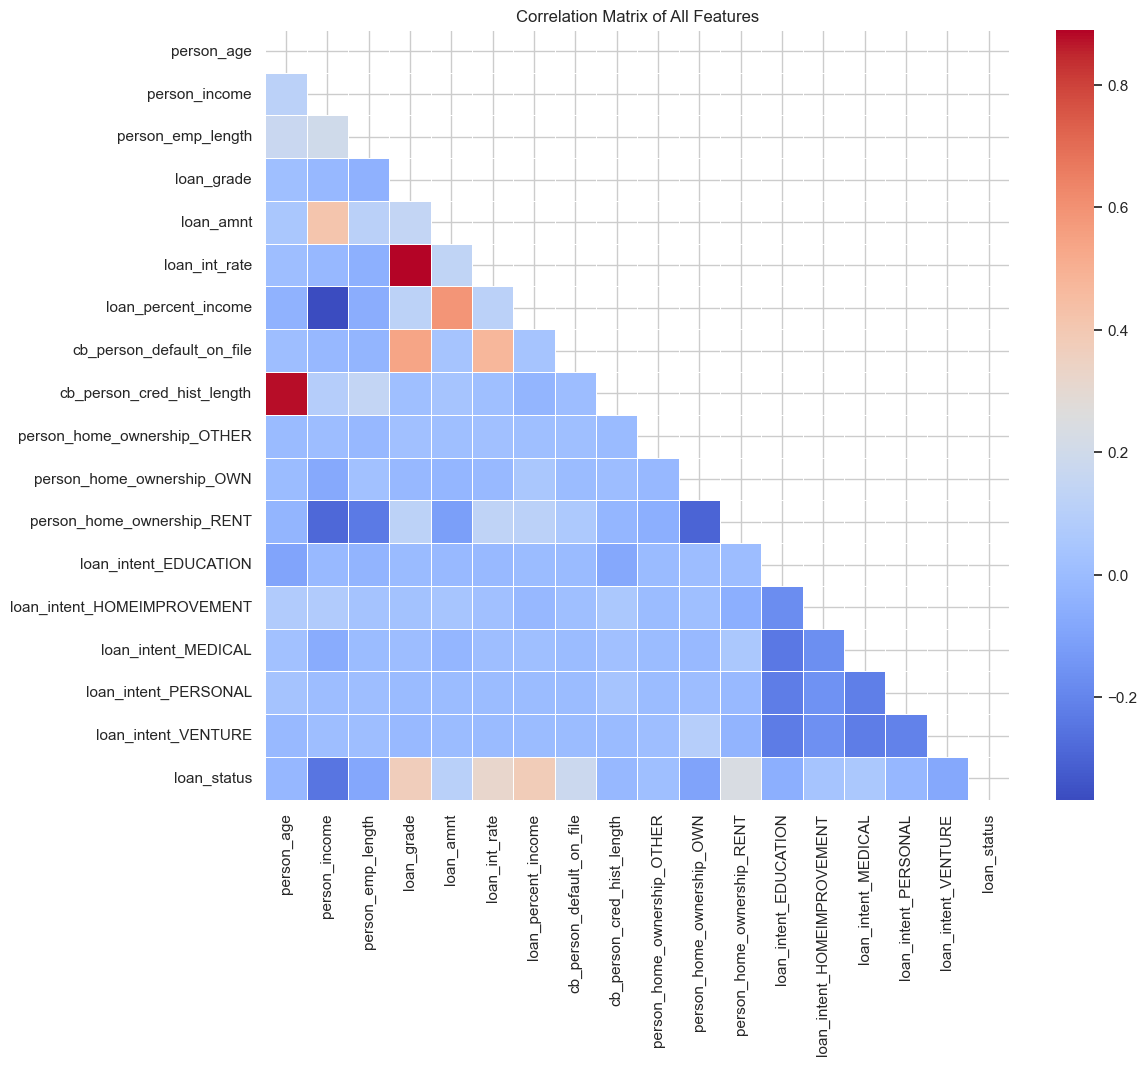

In [14]:
# Re-merge X and y to view correlations
df_final = pd.concat([X, y], axis=1)

# Compute correlation matrix (ensure we only use numeric columns to prevent ValueError)
corr_matrix = df_final.select_dtypes(include=['int64', 'float64', 'bool', 'uint8']).corr()

# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()

In [15]:
# Detect highly correlated features (> 0.8)
highly_correlated = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            highly_correlated.append((corr_matrix.columns[i], corr_matrix.columns[j]))

if highly_correlated:
    print("Found highly correlated feature pairs:")
    for pair in highly_correlated:
        print(pair)
    # If redundant features exist, drop them.
    # For example: X.drop(columns=[pair[1]], inplace=True)
else:
    print("No excessively highly correlated feature pairs found.")

Found highly correlated feature pairs:
('loan_int_rate', 'loan_grade')
('cb_person_cred_hist_length', 'person_age')


## 9. Train-Test Split & Feature Scaling Context
Before balancing the classes, it's extremely important to split our dataset into a Training set and a Testing set. 
*Concept Check:* If we balance the data (SMOTE) *before* splitting, synthetic data will leak into our testing set, resulting in artificially high model accuracy that won't hold up in the real world.


In [16]:
from sklearn.model_selection import train_test_split

# Our previously scaled X and y
X_ready = df_final.drop('loan_status', axis=1)
y_ready = df_final['loan_status']

# Split the data (80% training, 20% testing)
# stratify=y_ready ensures the ratio of defaults to non-defaults remains consistent in both splits
X_train, X_test, y_train, y_test = train_test_split(X_ready, y_ready, test_size=0.2, random_state=42, stratify=y_ready)

print(f"Training split: {X_train.shape[0]} rows")
print(f"Testing split: {X_test.shape[0]} rows")


Training split: 25927 rows
Testing split: 6482 rows


## 10. Class Imbalance Handling
Financial/Credit Risk datasets usually suffer from a severe class imbalance (e.g. non-defaults vastly outnumber loan defaults). 
To prevent supervised models from just blindly guessing 'No Default' every time, we apply **SMOTE** (Synthetic Minority Over-sampling Technique) to algorithmically balance the classes. 

**Important:** We ONLY apply this to the `X_train` data.


In [17]:
# You may need to run 'pip install imbalanced-learn' in your terminal if you don't have it.
try:
    from imblearn.over_sampling import SMOTE
    
    print("Class distribution BEFORE SMOTE:")
    print(y_train.value_counts())
    
    # Initialize and fit SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    print("\nClass distribution AFTER SMOTE:")
    print(y_train_smote.value_counts())
    
except ImportError:
    print("The 'imbalanced-learn' library is not installed. To run SMOTE, please execute:")
    print("!pip install imbalanced-learn")
    # Fallback to standard variables if SMOTE is unavailable locally
    X_train_smote, y_train_smote = X_train, y_train


Class distribution BEFORE SMOTE:
loan_status
0    20257
1     5670
Name: count, dtype: int64

Class distribution AFTER SMOTE:
loan_status
0    20257
1    20257
Name: count, dtype: int64


## 11. Model Training
With our data successfully prepared and synthetically balanced to combat class imbalance, we will now train the actual Machine Learning models!

As requested, we will deploy:
1. **Logistic Regression (LR)**
2. **Naive Bayes (NB)**


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore') # Suppress convergence warnings to keep output clean

# Initialize the models
lr_model = LogisticRegression(random_state=42, max_iter=1000)
nb_model = GaussianNB()

# Train the models on the SMOTE-balanced training data
print("Training Logistic Regression...")
lr_model.fit(X_train_smote, y_train_smote)

print("Training Naive Bayes...")
nb_model.fit(X_train_smote, y_train_smote)

print("\nModels successfully trained!")


Training Logistic Regression...
Training Naive Bayes...

Models successfully trained!


## 12. Step 3 — Performance Evaluation Matrix
We will now evaluate how our models survived! We will check them against the completely isolated `X_test` Testing Set using 5 specific metrics:
1. **Accuracy**: (TP+TN)/(TP+TN+FP+FN)
2. **Precision**: TP / (TP+FP)
3. **Recall**: TP / (TP+FN)
4. **F1 Score**: 2*(P*R)/(P+R)
5. **AUC-ROC**: Area under the ROC curve


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Generate predictions and probability scores for LR
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Generate predictions and probability scores for NB
y_pred_nb = nb_model.predict(X_test)
# Some Naive Bayes implementations might crash on proba, but GaussianNB supports it natively
y_prob_nb = nb_model.predict_proba(X_test)[:, 1] 

# Helper function to compute all 5 metrics cleanly
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

# Compute the metrics
metrics_lr = calculate_metrics(y_test, y_pred_lr, y_prob_lr)
metrics_nb = calculate_metrics(y_test, y_pred_nb, y_prob_nb)

# Display tabular metrics mapping to the Performance Evaluation Matrix in the graphic
metrics_df = pd.DataFrame({
    'Logistic Regression': metrics_lr, 
    'Naive Bayes': metrics_nb
})

print("====== PERFORMANCE EVALUATION MATRIX ======")
# Display as percentage scale to match graphic reference
display(metrics_df.round(4) * 100)


====== PERFORMANCE EVALUATION MATRIX ======


,Logistic Regression,Naive Bayes
Accuracy,79.02,77.21
Precision,51.34,48.69
Recall,78.42,77.57
F1 Score,62.05,59.83
AUC-ROC,86.44,84.30


### Confusion Matrix — Logistic Regression (Sample)
Visual representation of True Positives, True Negatives, False Positives, and False Negatives.


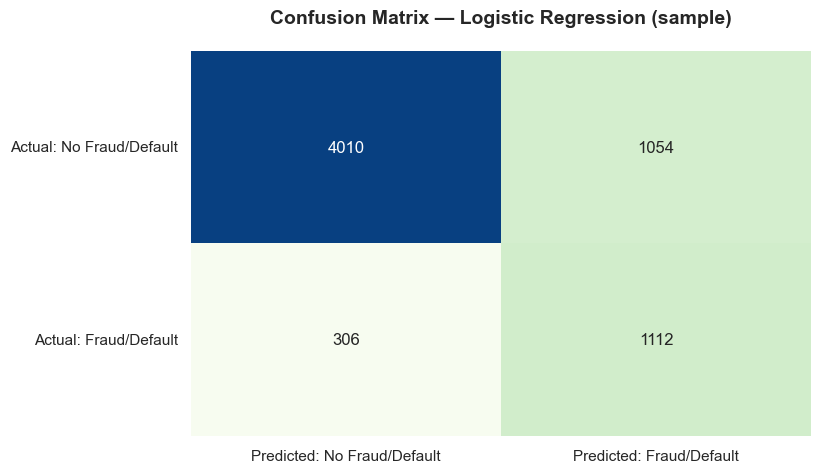

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 5))
# Custom heatmap mimicking the requested visual layout
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='GnBu', cbar=False,
            xticklabels=['Predicted: No Fraud/Default', 'Predicted: Fraud/Default'],
            yticklabels=['Actual: No Fraud/Default', 'Actual: Fraud/Default'])

plt.title('Confusion Matrix — Logistic Regression (sample)', pad=20, fontsize=14, fontweight='bold')
plt.yticks(rotation=0)
plt.show()


### Model Comparison (%)
A Side-by-Side Grouped Bar Chart comparing Logistic Regression and Naive Bayes metrics.


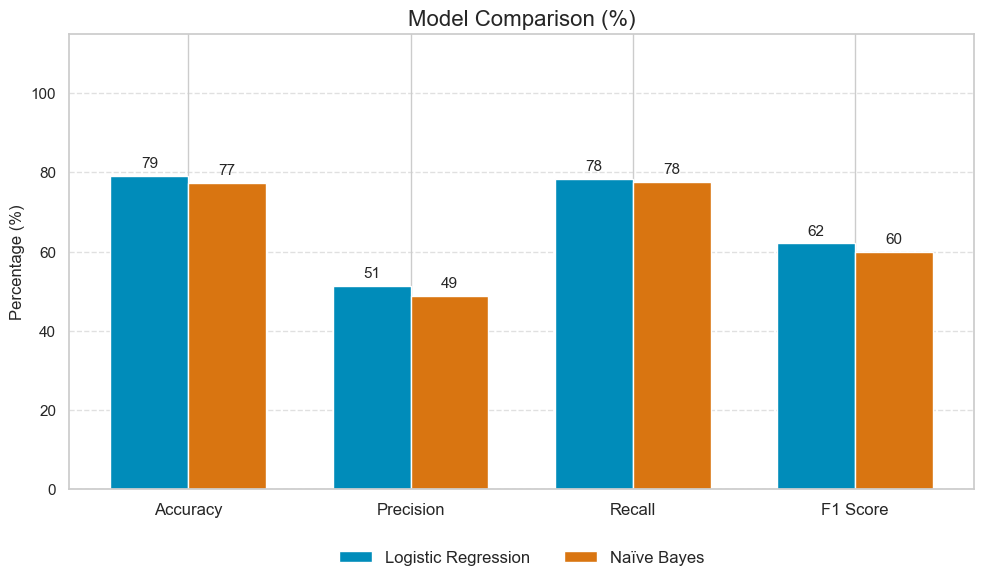

In [21]:
import numpy as np

# Set up the grouped bar chart data (Accuracy, Precision, Recall, F1 Score)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Extract direct percentage values
lr_scores = [metrics_lr[m] * 100 for m in metrics_names]
nb_scores = [metrics_nb[m] * 100 for m in metrics_names]

# Configure bar positions
x = np.arange(len(metrics_names))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))

# Use Teal and Orange to explicitly match the assignment graphic's color scheme
rects1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#008CBA') 
rects2 = ax.bar(x + width/2, nb_scores, width, label='Naïve Bayes', color='#d97511')        

# Label Customizations
ax.set_ylabel('Percentage (%)')
ax.set_title('Model Comparison (%)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=12)
ax.set_ylim(0, 115) # Leave room above bars for numbers

# Auto-label Function
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Ensure we don't display a text on 0 height blocks
        if height > 0:
            ax.annotate(f'{int(round(height))}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11)

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
